In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    precision_recall_fscore_support
)

# Load & chuẩn bị dữ liệu
df = pd.read_csv("./winequality-red.csv")

X = df.drop("quality", axis=1).values
y = df["quality"].values

print("Shape X:", X.shape)
print("Quality values:", np.unique(y))


# Encode nhãn ( chuyển đổi nhãn thành số từ 0 đến num_classes - 1 )
classes = np.unique(y)
class_to_idx = {c: i for i, c in enumerate(classes)}

y_idx = np.array([class_to_idx[i] for i in y])
num_classes = len(classes)

print("Class mapping:", class_to_idx)

# One-hot encoding
def one_hot(y, num_class):
    m = len(y)
    oh = np.zeros((m, num_class))
    oh[np.arange(m), y] = 1
    return oh

# Split data + Chuẩn hóa
X_train, X_test, y_train, y_test = train_test_split(
    X, y_idx,
    test_size=0.2,
    random_state=42,
    stratify=y_idx
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Y_train = one_hot(y_train, num_classes)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

# Softmax & Loss function
def softmax(z):
    z = z - np.max(z)
    exp = np.exp(z)
    return exp / np.sum(exp)

def loss_function(y, y_hat):
    return -np.sum(y * np.log(y_hat + 1e-9))

# Train Softmax Regression (SGD)
def train_softmax(X, Y, lr=0.01, epochs=1000):
    m, n = X.shape
    k = Y.shape[1]

    Xb = np.hstack([np.ones((m,1)), X])
    theta = np.random.randn(k, n+1) * 0.01

    losses = []

    for epoch in range(epochs):
        total_loss = 0

        for i in range(m):
            x = Xb[i].reshape(-1,1)
            y = Y[i].reshape(-1,1)

            z = theta @ x
            y_hat = softmax(z)

            loss = loss_function(y, y_hat)
            total_loss += loss

            grad = (y_hat - y) @ x.T
            theta -= lr * grad

        losses.append(total_loss / m)

    return theta, losses

# Train model
theta, losses = train_softmax(
    X_train,
    Y_train,
    lr=0.01,
    epochs=1000
)

# Predict
def predict(X, theta):
    m = X.shape[0]
    Xb = np.hstack([np.ones((m,1)), X])
    preds = []

    for i in range(m):
        z = theta @ Xb[i].reshape(-1,1)
        y_hat = softmax(z)
        preds.append(np.argmax(y_hat))

    return np.array(preds)

y_pred = predict(X_test, theta)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted")
recall = recall_score(y_test, y_pred, average="weighted")
f1 = f1_score(y_test, y_pred, average="weighted")

print(f"Accuracy : {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall   : {recall:.3f}")
print(f"F1-score : {f1:.3f}")

Shape X: (1599, 11)
Quality values: [3 4 5 6 7 8]
Class mapping: {np.int64(3): 0, np.int64(4): 1, np.int64(5): 2, np.int64(6): 3, np.int64(7): 4, np.int64(8): 5}
Train: (1279, 11)
Test: (320, 11)
Accuracy : 0.603
Precision: 0.584
Recall   : 0.603
F1-score : 0.583


c:\Users\TG\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


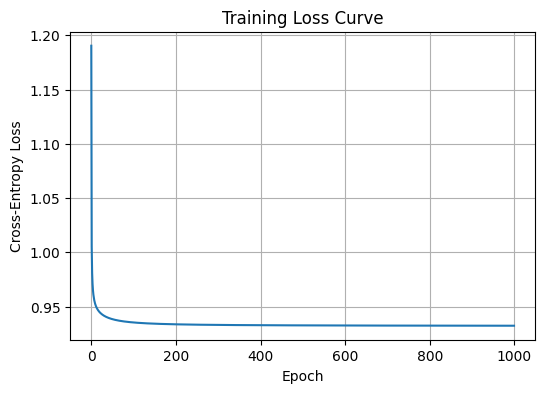

In [2]:
# Training Loss Curve
plt.figure(figsize=(6,4))
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.title("Training Loss Curve")
plt.grid(True)
plt.show()

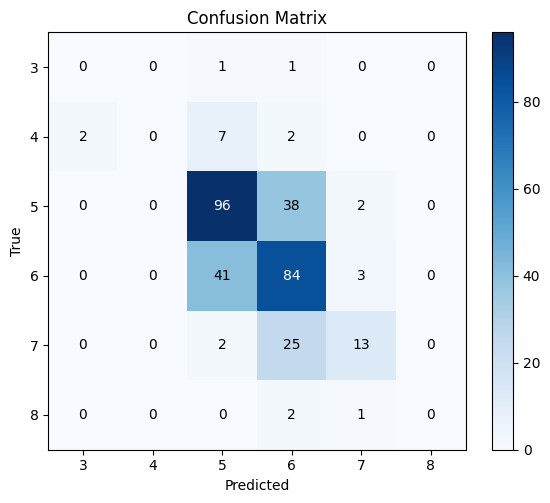

In [3]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
plt.imshow(cm, cmap="Blues")
plt.colorbar()
plt.title("Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("True")

plt.xticks(range(len(classes)), classes)
plt.yticks(range(len(classes)), classes)

# Ghi số TP, TN, FP, FN
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j],
                 ha="center", va="center",
                 color="white" if cm[i, j] > cm.max()/2 else "black")

plt.tight_layout()
plt.show()

In [4]:
cm = confusion_matrix(y_test, y_pred)

TP = np.diag(cm)
FP = np.sum(cm, axis=0) - TP
FN = np.sum(cm, axis=1) - TP
TN = np.sum(cm) - (TP + FP + FN)

for i, cls in enumerate(classes):
    print(f"Class {cls}:")
    print(f"  TP = {TP[i]}")
    print(f"  FP = {FP[i]}")
    print(f"  FN = {FN[i]}")
    print(f"  TN = {TN[i]}")

Class 3:
  TP = 0
  FP = 2
  FN = 2
  TN = 316
Class 4:
  TP = 0
  FP = 0
  FN = 11
  TN = 309
Class 5:
  TP = 96
  FP = 51
  FN = 40
  TN = 133
Class 6:
  TP = 84
  FP = 68
  FN = 44
  TN = 124
Class 7:
  TP = 13
  FP = 6
  FN = 27
  TN = 274
Class 8:
  TP = 0
  FP = 0
  FN = 3
  TN = 317


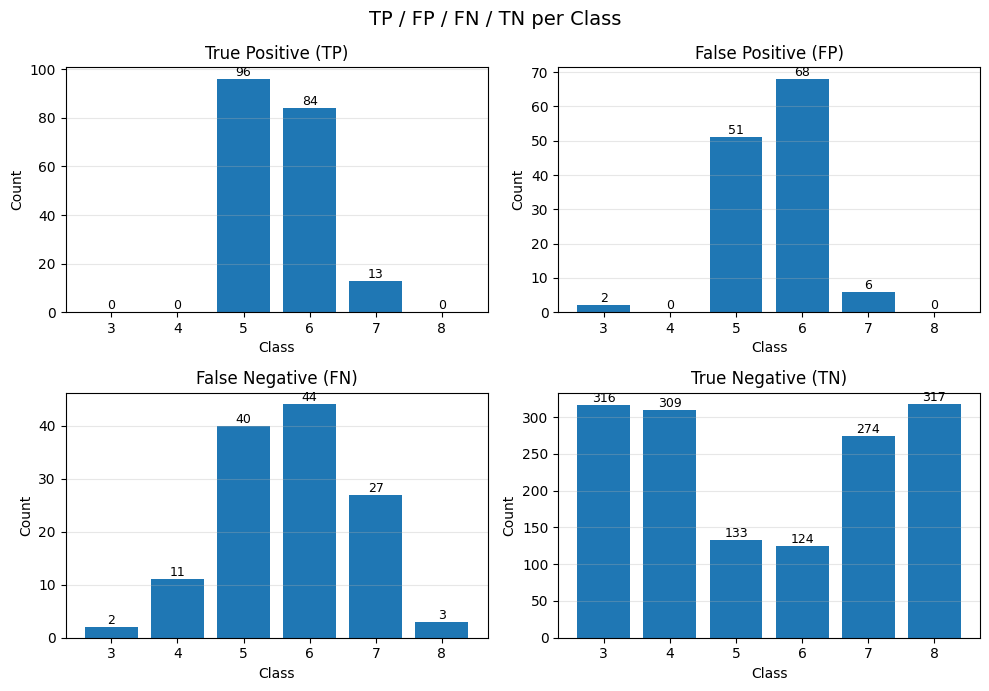

In [5]:
fig, axs = plt.subplots(2, 2, figsize=(10,7))

metrics = [TP, FP, FN, TN]
titles = ["True Positive (TP)", "False Positive (FP)",
          "False Negative (FN)", "True Negative (TN)"]

for ax, data, title in zip(axs.flatten(), metrics, titles):
    bars = ax.bar(classes, data)
    ax.set_title(title)
    ax.set_xlabel("Class")
    ax.set_ylabel("Count")
    ax.grid(axis="y", alpha=0.3)

    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f"{int(height)}",
            ha="center",
            va="bottom",
            fontsize=9
        )

plt.suptitle("TP / FP / FN / TN per Class", fontsize=14)
plt.tight_layout()
plt.show()
